In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os, shutil

local_path = '/content/chest_xray'

if not os.path.exists(local_path):
    print("Copying from Drive to Colab SSD...")
    shutil.copytree(
        '/content/drive/MyDrive/chest_xray/chest_xray',
        local_path
    )
    print("Done!")
else:
    print("Already copied, skipping.")

# Then just change this one line
data_path = local_path

Copying from Drive to Colab SSD...
Done!


In [ ]:
import os
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#!pip install kaggle

In [ ]:
#!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia -p /content/drive/MyDrive/

In [ ]:
#!unzip /content/drive/MyDrive/chest-xray-pneumonia.zip -d /content/drive/MyDrive/chest_xray/

In [ ]:
#!rm /content/drive/MyDrive/chest-xray-pneumonia.zip

In [ ]:
#!rm -r /content/drive/MyDrive/chest_xray/chest_xray/chest_xray
#!rm -r /content/drive/MyDrive/chest_xray/chest_xray/__MACOSX

In [ ]:
#data_path = "/content/drive/MyDrive/chest_xray/chest_xray"
#os.listdir('/content/drive/MyDrive/chest_xray/chest_xray')


In [ ]:
train_path = os.path.join(data_path, 'train')
val_path = os.path.join(data_path, 'val')
test_path = os.path.join(data_path, 'test')

### Dataset Exploration


{'PNEUMONIA': 3875, 'NORMAL': 1341}


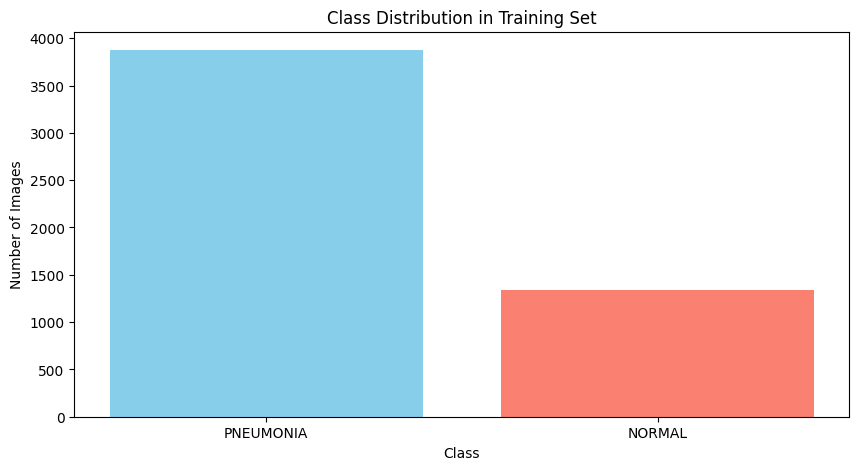

In [ ]:
class_counts={}

for class_name in os.listdir(train_path):
    class_path = os.path.join(train_path, class_name)
    if os.path.isdir(class_path): #if it is an existing floder
         count = len([
            img for img in os.listdir(class_path)
            if img.lower().endswith(('.jpeg', '.jpg', '.png'))
        ])
    class_counts[class_name] = count
print(class_counts)
plt.figure(figsize=(10, 5))
plt.bar(class_counts.keys(), class_counts.values(), color=['skyblue', 'salmon'])
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.title('Class Distribution in Training Set')


plt.show()

\- so clearly there are imbalance at the dataset


In [ ]:
import os

def count_files_in_directory(path):
    counts = {'NORMAL': 0, 'PNEUMONIA': 0}
    for root, dirs, files in os.walk(path):
      #os.walk returns the path , directories in it and the files in it
        for file in files:
            if 'NORMAL' in root and file.lower().endswith(('.jpeg', '.png', '.jpg')):
                counts['NORMAL'] += 1
            elif 'PNEUMONIA' in root and file.lower().endswith(('.jpeg', '.png', '.jpg')):
                counts['PNEUMONIA'] += 1
    return counts

data_path = '/content/drive/MyDrive/chest_xray/chest_xray/'

print(f"Exploring: {data_path}")



print("\n--- Training Data ---")
train_counts = count_files_in_directory(train_path)
print(f"Normal images: {train_counts['NORMAL']}")
print(f"Pneumonia images: {train_counts['PNEUMONIA']}")

print("\n--- Validation Data ---")
val_counts = count_files_in_directory(val_path)
print(f"Normal images: {val_counts['NORMAL']}")
print(f"Pneumonia images: {val_counts['PNEUMONIA']}")

print("\n--- Test Data ---")
test_counts = count_files_in_directory(test_path)
print(f"Normal images: {test_counts['NORMAL']}")
print(f"Pneumonia images: {test_counts['PNEUMONIA']}")

Exploring: /content/drive/MyDrive/chest_xray/chest_xray/

--- Training Data ---
Normal images: 1341
Pneumonia images: 3875

--- Validation Data ---
Normal images: 8
Pneumonia images: 8

--- Test Data ---
Normal images: 234
Pneumonia images: 390


### Display Sample Images


In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random

def display_sample_images(base_path, category, num_images=3):
    category_path = os.path.join(base_path, category)
    images = [os.path.join(category_path, f) for f in os.listdir(category_path) if f.lower().endswith(('.jpeg', '.png', '.jpg'))]

    plt.figure(figsize=(15, 5))
    plt.suptitle(f'Sample {category} Images', fontsize=16)

    # Select random images if there are enough, otherwise take all available
    sample_images = random.sample(images, min(num_images, len(images)))

    for i, img_path in enumerate(sample_images):
        plt.subplot(1, num_images, i + 1)
        img = Image.open(img_path).convert('L') # Convert to grayscale
        plt.imshow(img, cmap='gray')
        plt.title(os.path.basename(img_path))
        plt.axis('off')
    plt.show()





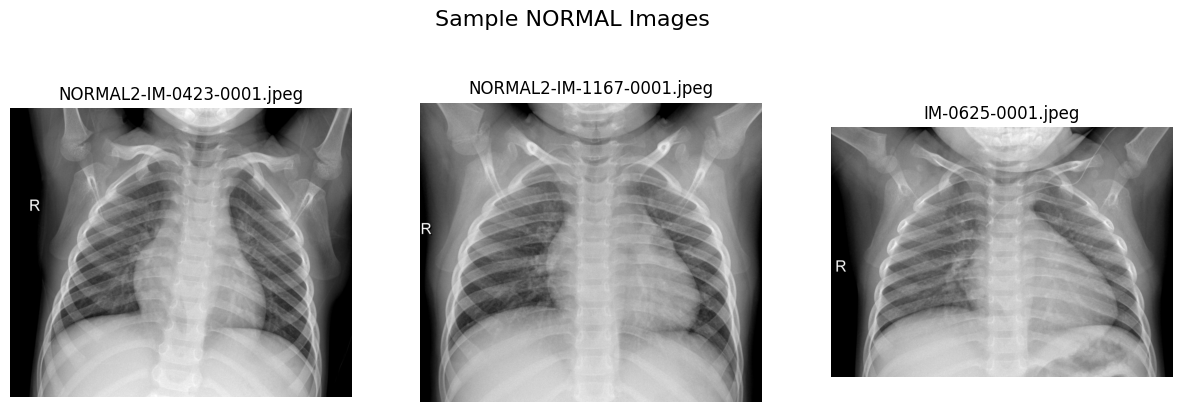

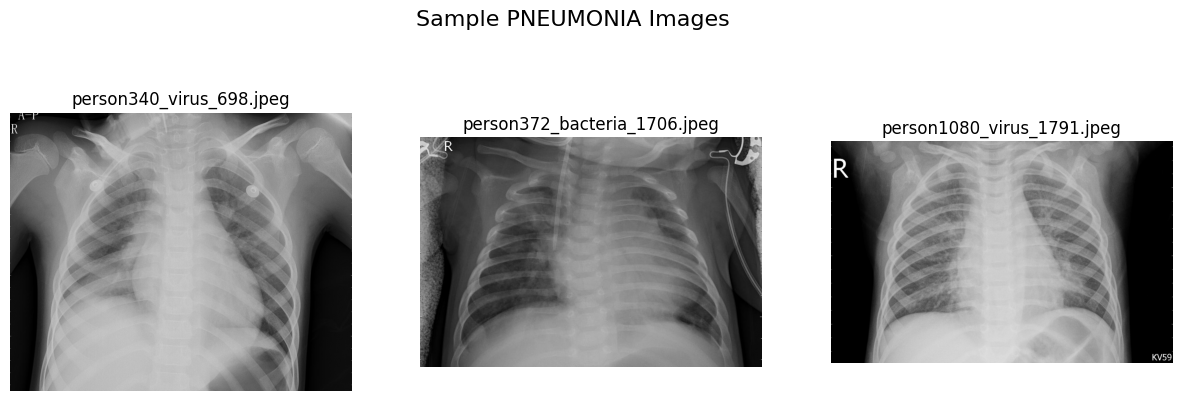

In [ ]:
# Display sample images from the training set
display_sample_images(train_path, 'NORMAL')
display_sample_images(train_path, 'PNEUMONIA')


## preprocessing

In [ ]:
import tensorflow as tf # type: ignore
from tensorflow.keras.preprocessing.image import ImageDataGenerator # type: ignore
from tensorflow.keras.layers import Conv2D,MaxPool2D,Dense,Dropout,Flatten # type: ignore
from tensorflow.keras.models import Sequential # type: ignore

### image augmentation

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator#type:ignore

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2        # ← carve 20% out for validation
)

test_datagen = ImageDataGenerator(rescale=1./255)

# Training slice (80% of train folder = ~4173 images)
training_set = train_datagen.flow_from_directory(
    train_path,
    target_size=(64, 64),
    batch_size=64,
    class_mode='binary',
    shuffle=True,
    seed=42,
    subset='training'           # 80%
)

# Validation slice (20% of train folder = ~1043 images)
validation_set = train_datagen.flow_from_directory(
    train_path,
    target_size=(64, 64),
    batch_size=64,
    class_mode='binary',
    shuffle=False,#TRUE
    seed=42,
    subset='validation'         # 20%
)

# Test set
test_set = test_datagen.flow_from_directory(
    test_path,
    target_size=(64, 64),
    batch_size=64,
    class_mode='binary',
    shuffle=False#TRUE
)

print(f"Training samples   : {training_set.samples}")
print(f"Validation samples : {validation_set.samples}")
print(f"Test samples       : {test_set.samples}")

Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Training samples   : 4173
Validation samples : 1043
Test samples       : 624


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np




#balancing
class_weights=compute_class_weight(
    'balanced',
    classes=np.unique(training_set.classes),
    y=training_set.classes
)

weight_dict = {0: class_weights[0], 1: class_weights[1]}
print(weight_dict)

{0: np.float64(1.9445479962721341), 1: np.float64(0.6730645161290323)}


In [ ]:
print(training_set.class_indices)

{'NORMAL': 0, 'PNEUMONIA': 1}


In [ ]:
print(f"Validation samples: {validation_set.samples}")
print(f"Validation batches: {len(validation_set)}")

Validation samples: 1043
Validation batches: 17


## Building the model

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 8)      │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 155,857 (608.82 KB)

 Trainable params: 155,857 (608.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/12
66/66 ━━━━━━━━━━━━━━━━━━━━ 68s 896ms/step - accuracy: 0.4903 - loss: 0.6406 - val_accuracy: 0.8159 - val_loss: 0.4441 - learning_rate: 0.0010
Epoch 2/12
66/66 ━━━━━━━━━━━━━━━━━━━━ 49s 753ms/step - accuracy: 0.8493 - loss: 0.3551 - val_accuracy: 0.8351 - val_loss: 0.3541 - learning_rate: 0.0010
Epoch 3/12
66/66 ━━━━━━━━━━━━━━━━━━━━ 51s 775ms/step - accuracy: 0.8608 - loss: 0.3143 - val_accuracy: 0.8878 - val_loss: 0.2599 - learning_rate: 0.0010
Epoch 4/12
66/66 ━━━━━━━━━━━━━━━━━━━━ 49s 746ms/step - accuracy: 0.8876 - loss: 0.2565 - val_accuracy: 0.9012 - val_loss: 0.2362 - learning_rate: 0.0010
Epoch 5/12
66/66 ━━━━━━━━━━━━━━━━━━━━ 50s 759ms/step - accuracy: 0.8924 - loss: 0.2401 - val_accuracy: 0.8907 - val_loss: 0.2464 - learning_rate: 0.0010
Epoch 6/12
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 597ms/step - accuracy: 0.9218 - loss: 0.1969
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
66/66 ━━━━━━━━━━━━━━━━━━━━ 49s 739ms/step - accuracy: 0.9099 - loss: 0.21

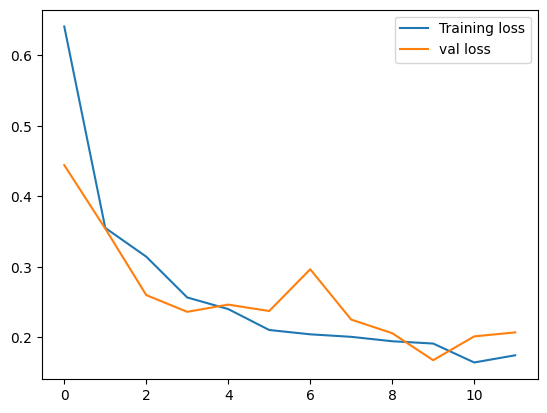

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping #type:ignore
from tensorflow.keras.layers import Conv2D,MaxPool2D,Dense,Dropout,Flatten, Input# type: ignore
from tensorflow.keras.models import Sequential # type: ignore
from tensorflow.keras.callbacks import ReduceLROnPlateau # type: ignore
from tensorflow.keras.optimizers import Adam # type: ignore
model = Sequential([
    Input(shape=(64, 64, 3)),

    # Block 1
    Conv2D(8, (3, 3), activation='relu', padding='same'),
    MaxPool2D(pool_size=2, strides=2),
    Dropout(0.1),  # Added dropout

    # Block 2
    Conv2D(16, (3, 3), activation='relu', padding='same'),
    MaxPool2D(pool_size=2, strides=2),
    Dropout(0.3),

    # Block 3
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPool2D(pool_size=2, strides=2),
    Dropout(0.2),

    # Block 4 (Added for better feature extraction)
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPool2D(pool_size=2, strides=2),
    Dropout(0.2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

# Summary
#callbacks = [
 #   EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
  #  ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1)
#]

model.compile(optimizer=Adam(learning_rate=1e-3),loss='binary_crossentropy',metrics=['accuracy'])



model.summary()
history = model.fit(
    training_set,
    epochs=12,
    class_weight=weight_dict,
    validation_data=validation_set,
    callbacks = [
    EarlyStopping(monitor='val_accuracy', mode='max', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1)
]
)

loss, accuracy = model.evaluate(test_set)
print(f"Test Accuracy: {accuracy * 100:.2f}%")
plt.plot(history.history["loss"],label="Training loss")
plt.plot(history.history["val_loss"],label="val loss")
plt.legend()
plt.show()

10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 403ms/step
              precision    recall  f1-score   support

      NORMAL       0.92      0.68      0.79       234
   PNEUMONIA       0.84      0.97      0.90       390

    accuracy                           0.86       624
   macro avg       0.88      0.83      0.84       624
weighted avg       0.87      0.86      0.86       624



<Axes: >

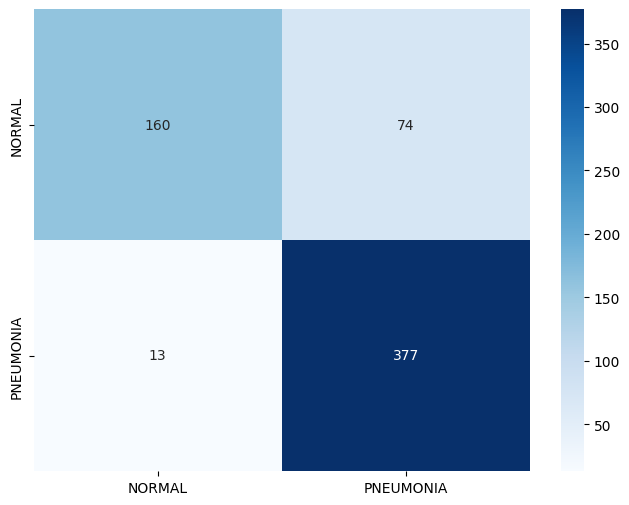

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get predictions
predictions = (model.predict(test_set) > 0.5).astype(int)
true_labels = test_set.classes

# Detailed report
print(classification_report(true_labels, predictions,
                           target_names=['NORMAL', 'PNEUMONIA']))

# Confusion matrix
cm = confusion_matrix(true_labels, predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NORMAL', 'PNEUMONIA'],
            yticklabels=['NORMAL', 'PNEUMONIA'])

In [ ]:
model.save("pneumonia_model.keras")

## Pretrained Model

In [ ]:
from tensorflow.keras.applications import ResNet50 #type:ignore
from tensorflow.keras.applications.resnet50 import preprocess_input #type:ignore
from tensorflow.keras import layers #type:ignore
from tensorflow.keras.preprocessing.image import ImageDataGenerator #type:ignore
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau #type:ignore
import tensorflow as tf #type:ignore

#  Data
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_data = train_datagen.flow_from_directory(
    train_path, target_size=(224,224), batch_size=64,
    class_mode='binary',
    shuffle=True,
    seed=42, subset='training'
)

val_data = train_datagen.flow_from_directory(
    train_path, target_size=(224,224), batch_size=64,
    class_mode='binary',
    shuffle=False,
    seed=42, subset='validation'
)

test_data = test_datagen.flow_from_directory(
    test_path, target_size=(224,224), batch_size=64,
    class_mode='binary',
    shuffle=False
)

#  Model
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False   # freeze backbone for phase 1

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)  # ← helps stabilise ResNet specifically
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.35)(x)
output = layers.Dense(1, activation='sigmoid')(x)

model2 = tf.keras.Model(inputs=base_model.input, outputs=output)

#  Phase 1: train head only
model2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model2.summary()

callbacks = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1)
]

print("── Phase 1: head only ──")
history1 = model2.fit(
    train_data,
    epochs=10,
    validation_data=val_data,
    callbacks=callbacks,class_weight=weight_dict
)

Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,858,305 (91.01 MB)

 Trainable params: 266,497 (1.02 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

── Phase 1: head only ──
Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 139s 955ms/step - accuracy: 0.9279 - loss: 0.2068 - val_accuracy: 0.9214 - val_loss: 0.1771 - learning_rate: 0.0010
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 106s 809ms/step - accuracy: 0.9549 - loss: 0.1007 - val_accuracy: 0.9549 - val_loss: 0.1086 - learning_rate: 0.0010
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 109s 832ms/step - accuracy: 0.9614 - loss: 0.1062 - val_accuracy: 0.9434 - val_loss: 0.1467 - learning_rate: 0.0010
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 730ms/step - accuracy: 0.9692 - loss: 0.0840
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
131/131 ━━━━━━━━━━━━━━━━━━━━ 116s 885ms/step - accuracy: 0.9645 - loss: 0.0984 - val_accuracy: 0.9578 - val_loss: 0.1317 - learning_rate: 0.0010
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 108s 825ms/step - accuracy: 0.9729 - loss: 0.0784 - val_accuracy: 0.9425 - val_loss: 0.1845 - learning_rate: 5.0000e-04
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━

In [ ]:
base_model.trainable = True
for layer in base_model.layers[:-10]:
    layer.trainable = False

model2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("── Phase 2: fine-tuning ──")
history2 = model2.fit(
    train_data,
    epochs=10,
    validation_data=val_data,
    callbacks=callbacks,class_weight=weight_dict
)

loss, accuracy = model2.evaluate(test_data)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

── Phase 2: fine-tuning ──
Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 135s 918ms/step - accuracy: 0.9811 - loss: 0.0537 - val_accuracy: 0.9751 - val_loss: 0.0720 - learning_rate: 1.0000e-05
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 105s 797ms/step - accuracy: 0.9818 - loss: 0.0469 - val_accuracy: 0.9693 - val_loss: 0.0858 - learning_rate: 1.0000e-05
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 104s 798ms/step - accuracy: 0.9803 - loss: 0.0480 - val_accuracy: 0.9751 - val_loss: 0.0684 - learning_rate: 1.0000e-05
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 105s 800ms/step - accuracy: 0.9789 - loss: 0.0526 - val_accuracy: 0.9741 - val_loss: 0.0778 - learning_rate: 1.0000e-05
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 634ms/step - accuracy: 0.9844 - loss: 0.0420
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
131/131 ━━━━━━━━━━━━━━━━━━━━ 103s 785ms/step - accuracy: 0.9847 - loss: 0.0385 - val_accuracy: 0.9770 - val_loss: 0.0718 - learning_rate: 1.0000e-05
Epoch 6/10
131/131 ━

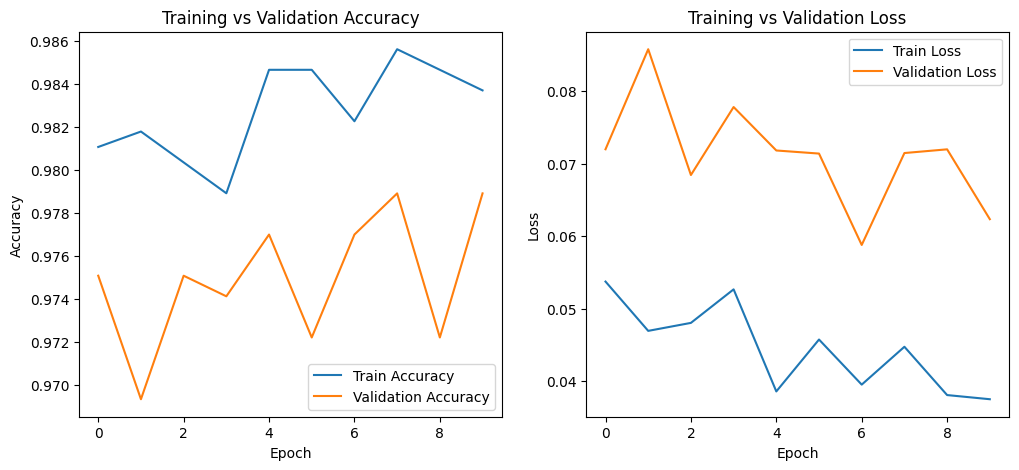

In [ ]:


plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)

plt.plot(history2.history['accuracy'], label='Train Accuracy')
plt.plot(history2.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)

plt.plot(history2.history['loss'], label='Train Loss')
plt.plot(history2.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 163ms/step
              precision    recall  f1-score   support

      NORMAL       0.88      0.83      0.85       234
   PNEUMONIA       0.90      0.93      0.92       390

    accuracy                           0.89       624
   macro avg       0.89      0.88      0.89       624
weighted avg       0.89      0.89      0.89       624



<Axes: >

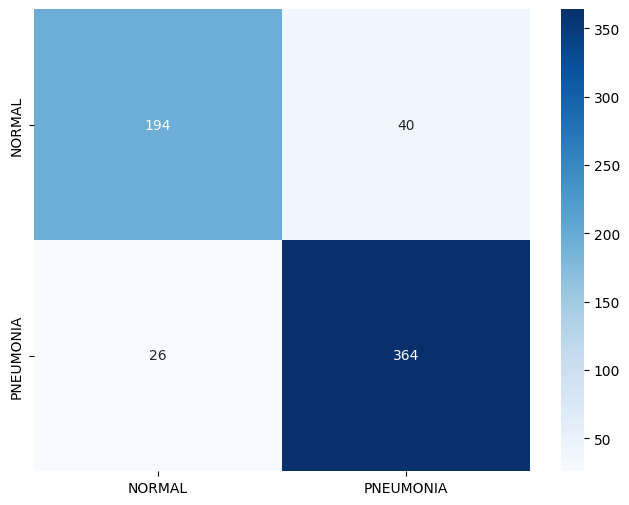

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

test_data.reset()

# Get predictions
predictions2 = (model2.predict(test_data) > 0.5).astype(int)
true_labels2 = test_data.classes

# Detailed report
print(classification_report(true_labels2, predictions2,
                           target_names=['NORMAL', 'PNEUMONIA']))

# Confusion matrix
cm = confusion_matrix(true_labels2, predictions2)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NORMAL', 'PNEUMONIA'],
            yticklabels=['NORMAL', 'PNEUMONIA'])

In [ ]:
# Check test set size and composition
print(f"Test samples: {test_set.samples}")
print(f"Test class distribution:")
for class_name, class_idx in test_set.class_indices.items():
    count = sum(1 for label in test_set.classes if label == class_idx)
    print(f"  {class_name}: {count}")

# Calculate per-class performance on test
from sklearn.metrics import classification_report
predictions = (model.predict(test_set) > 0.5).astype(int)
print(classification_report(test_set.classes, predictions,
                           target_names=['NORMAL', 'PNEUMONIA']))

# This will reveal if one class is performing poorly

Test samples: 624
Test class distribution:
  NORMAL: 234
  PNEUMONIA: 390
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 349ms/step
              precision    recall  f1-score   support

      NORMAL       0.92      0.68      0.79       234
   PNEUMONIA       0.84      0.97      0.90       390

    accuracy                           0.86       624
   macro avg       0.88      0.83      0.84       624
weighted avg       0.87      0.86      0.86       624



In [ ]:
model2.save("pneumonia_model_resnet50.keras")